# <font color="blue">**Prediction of Breast Cancer Tumours using logistic regression**

# <font color="green"> **Introduction**</font>


We are working with a modified version of the Breast Cancer Wisconsin dataset. The dataset includes characteristics of breast masses obtained through Fine Needle Aspiration (FNA), along with patient age and confirmed diagnoses indicating whether the tumour is benign or malignant. Our main stakeholder is the clinician, and the health question we aim to answer is **to classify breast tumours as malignant or benign based on FNA-derived features and patient age**.

#### **1. Tumour**
In this context, a tumour is considered malignant (positive) if it is diagnosed as cancer, and benign (negative) if it is non-cancerous. A malignant tumour is cancerous. The progression of a malignant tumour is rapid and may involve metastasis, the spread to other parts of the body. Therefore, malignant tumours are life-threatening and require timely medical intervention.

In contrast, a benign tumour is non-cancerous. Its progression is slow and does not invade surrounding tissues, nor does it spread. Although it is less dangerous than malignant tumours, benign tumours may still require removal or monitoring depending on their location and size.


#### **2. Importance**

Therefore, accurate classification of tumour types is critical. Identifying malignant tumours early allows timely treatment, improving patient survival and outcomes. Correctly identifying benign tumours is also important to avoid unnecessary procedures, emotional distress, and possible side effects from aggressive treatments such as chemotherapy.

#### **3. Implications**
Misclassification can have serious consequences:

* **A false negative** (malignant tumour predicted as benign) may lead to delayed diagnosis, disease progression, and reduced survival chances.

* **A false positive** (benign tumour predicted as malignant) can cause emotional distress, financial burden, unnecessary invasive treatments, and even medical complications.

Hence, it is important to consider the false classifications when building diagnostic model to avoid unnecessary physical and mental impacts.


Now that we have defined our health question — to determine whether a tumour is malignant or benign based on features derived from Fine Needle Aspiration (FNA) — we reframe this as a data science problem.

#### **4. Classification Goal**  
This is a **binary classification problem**.
We aim to build a machine learning model that outputs a categorical dependent variable, predicting tumour diagnosis as either:

* Benign (0) or
* Malignant (1)


#### **5. Method Selection**  
We selected **logistic regression model** as the most appropriate method to solve this binary classification problem for the following reasons:

* Logistic regression is specifically designed for binary classification, making it a natural fit for predicting whether a tumour is malignant (1) or benign (0).

* The dataset consists of only 580 samples, which is relatively small. More complex models such as tree-based methods may overfit on such limited data and require careful tuning.

* Logistic regression provides interpretable coefficients, which are important in healthcare applications. Clinicians can understand how each feature contributes to the prediction, which promotes transparency and trust in the model’s decision-making process.

* It also outputs class probabilities, helping clinicians not only see the predicted class but also assess the likelihood of malignancy, which supports risk-based medical decision-making.

* Additionally, logistic regression is computationally efficient and runs well in constrained environments such as Google Colab.

* The model allows for regularization (L1 or L2) to prevent overfitting and enable feature selection.

* It supports handling class imbalance through class_weight='balanced' or custom weights, which is important if malignant and benign cases are unevenly distributed.

Given these reasons, logistic regression is a strong, interpretable, and medically suitable model for this classification task.

#### **6. Method Evaluation – Success Criteria**  
In this cancer classification task, we select **F1-score** as our primary evaluation metric, as it provides a balanced measure between precision and recall.

Precision measures how many of the tumours predicted as malignant are actually malignant. This is useful when false positives are a concern — for example, when benign patients are incorrectly diagnosed with cancer, which could lead to unnecessary emotional stress, medical treatment, and financial burden.

On the other hand, recall captures how many of the actual malignant tumours are correctly identified by the model. This is particularly critical in a medical context, since false negatives — where cancerous tumours are misclassified as benign — can lead to missed opportunities for early treatment and worse patient outcomes.

While recall is more important than precision in this context due to the life-threatening nature of missed cancer diagnoses, avoiding false positives is also relevant, as discussed above.

Therefore, we choose F1-score as the primary metric to balance these two considerations, with recall as the secondary metric to ensure malignant cases are not overlooked.

Furthermore, as we will illustrate in EDA section, the diagnosis classes are imbalanced. In such cases, the F1-score is an appropriate evaluation metric, as it effectively accounts for both false positives and false negatives.


#### **7. Data**  
We use the modified version of the Breast Cancer Wisconsin dataset. Each row represents a patient case and includes:

* A unique ID

* A diagnosis label (M = malignant, B = benign, X = rare class)

* 30 numerical features capturing characteristics of cell nuclei from digitized images of fine needle aspirates (e.g., radius, texture, perimeter, area, smoothness, concavity, symmetry)

* Each of these features includes mean, standard error, and worst-case values, resulting in a rich set of 30 predictors.

* An additional ‘age’ variable and a duplicate diagnosis column are present but may need review for preprocessing.

This structured data provides a solid basis for exploring classification models to support early cancer detection. Further preprocessing and EDA will be conducted in later stages.

#### **8. Hardware**  
The dataset contains only 580 rows and 30 numerical features. Given its small size and the simplicity of the logistic regression model, it is computationally lightweight. Therefore, **Google Colab's standard CPU environment** is sufficient to handle data processing, model training, and evaluation efficiently without requiring GPU or additional resources.

#### **9. Software and Libraries**  
To build and evaluate the classification model, we use the ***Python*** programming language with the following libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

* **Pandas**: Used to read data files, create DataFrames, and perform preprocessing tasks such as generating dummy variables for categorical features. It provided a convenient and efficient way to manipulate structured medical data.

* **NumPy**: Used to create and manipulate arrays, including converting lists to 2D arrays and reshaping array dimensions.

* **Matplotlib** & **Seaborn**: These libraries were used for data visualization. Seaborn helped in generating clear and informative heatmaps during hyperparameter tuning, while Matplotlib enabled customized plotting.


* **Scikit-learn**:

  * **train_test_split**: Used to divide the dataset into training and testing sets.

  * **Pipeline**: Helped structure preprocessing and modeling steps into a streamlined workflow.

  * **StandardScaler**: Standardized features to put features on the smae scale/

  * **LogisticRegression**: The model used for binary classification of tumors (benign vs. malignant).

  * **GridSearchCV**: Enabled systematic hyperparameter tuning (e.g., regularization strength, penalty term, class weights) using cross-validation.

  * **classification_report**: Used to summarize precision, recall, and F1 scores, providing a detailed view of model performance.

#### **10. Version Control**  
Since we are working in Google Colab, we will manually manage versions by dividing code into sections and saving checkpoints. After each major change (e.g., feature engineering, model training), we create new versions of the notebook (e.g., *_ver0*, *_ver1*, ...) with incremental filenames. If an issue arises, we can roll back to a previous version easily.

This lightweight approach is sufficient for small, individual projects. However, in larger projects or collaborative settings, Git and GitHub would be more suitable alternatives for professional version control, allowing for branch management, detailed change logs, and team collaboration.


#### **11. Table of Variables and Constants**  
   The *all* variables and constants used in this notebook are presented below along with their definitions.
   

   * **df**: new Breast Cancer Wisconsin dataset loaded into a dataframe
   * **X** : dataframe containing predictors used to predict diagnosis
   * **y** : Target variable where 1 = malignant and 0 = benign
   * **X_train** : predictors used for training the model
   * **y_train** : target varialbes corresponding to X_train
   * **X_test** : predictors used for testing the model
   * **y_test** : target varialbes corresponding to X_test
   * **correlation** : correlation values between all features and the target variable diagnosis
   * **top_features** : top2 predictors most correlated with the target variable, diagnosis
   * **log_reg** : LogisticRegression object initialized with liblinear solver, used as the base model for classification
   * **pipeline** : defines the sequence of data processing and modeling steps. It includes standardisation and logistic regression.
   * **param_grid** : dictionary that defines the hyperparameter search space (penalty type, regularization strength C, and class weight settings) for GridSearchCV
   * **gs_log_reg** : GridSearchCV object that performs cross-validated grid search on the pipeline to find the best combination of hyperparameters
   * **best_model** : the best estimator selected by GridSearchCV, which combines the optimal hyperparameters (C=0.5, penalty='l2', class_weight={1: 0.6, 0: 0.4}) and the trained pipeline model. This model achieved the highest F1 score during cross-validation.
   * **scaler** : the name assigned to the StandardScaler in the pipeline for identification.
   * **classifier** : the name used in the pipeline to identify the classifier (Logistic Regression)
   * **cv** : number of cross-validation folds used in GridSearchCV
   * **n_jobs** : specifies the number of jobs to run in parallel used when performing operations like cross-validation.
   * **scoring** : strategy to evaluate the performance of the cross-validated model on the test set.
   * **classifier__penalty** : the type of regularization used in Logistic Regression.
   * **classifier__C** : inverse of the regularization strength.
   * **classifier__class_weight** : weights associated with classes in the form {class_label: weight}.
   * **solver** : the algorithm used to optimize the cost function in logistic regression.
   * **best_params** : parameter setting that gave the best results on the hold out data.
   * **best_score**: mean cross-validated score of the best_estimator
   * **predictions_train**: the predicted labels for the training set generated by the best model.
   * **train_score** : the F1 score on the training set using the best model.
   * **predictions_test**: the predicted labels for the test set generated by the best model.
   * **test_score** : the F1 score on the test set using the best model.
   * **results_df** : a dataFrame created from cv_results_ of GridSearchCV, containing the cross-validation results.
   * **grouped** : a grouped version of results_df by each unique value of hyperparameter.
   * **find_columns** : a list of column names in grouped that correspond to test scores from each CV split.
   * **scores_by_fold_C** : a 2D NumPy array where each row is a fold and each column is a unique value of C.
   * **mean_scores_by_C** : a 1D array containing the average test scores (F1 score) across all folds for each value of C.
   * **mean_scores_C_2d** : a reshaped 2D version of mean_scores_by_C for use in the heatmap.
   * **filtered_df_penalty**:	a DataFrame filtered to include only rows with specific C and class_weight values.
   * **scores_by_fold_penalty**: a 2D NumPy array where each row is a fold and each column is a unique value of penalty.
   * **mean_scores_penalty**: an array of mean test scores (averaged across folds) for each penalty type.
   * **mean_scores_penalty_2d** : a reshaped 2D version of mean_scores_penalty to be used for the heatmap.
   * **scores_by_fold_weight**: a 2D NumPy array where each row is a fold and each column is a unique value of class weight.
   * **mean_scores_weight**: an array of mean test scores (averaged across folds) for each class weight type.
   * **mean_scores_weight_2d** : a reshaped 2D version of mean_scores_weight to be used for the heatmap.
   



---



---



---



# <font color="green"> **Exploratory Data Analysis**</font>


In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/cbdrh-HDAT9500-T2-2025/Data-Project-1/refs/heads/main/FNA-Breast-Cancer-Tumour-Dataset.csv'
df = pd.read_csv(url)

In [ ]:
df

,ID,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age,diagnosis_dup
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,184.6,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,5,M
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,158.8,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,105,M
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,152.5,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,5,M
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,98.9,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,5,M
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,152.2,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,5,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,166.1,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,5,M
576,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,155.0,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,5,M
577,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,126.7,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,88,M
578,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,184.6,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,88,M


## Perform exploratory data analysis on the [dataset](https://drive.google.com/file/d/1F5vzyK32L4JSckD9-_nvoF003v_GqLu7/view?usp=sharing), and then prepare it for subsequent steps.

Apart from any other steps you deem relevant for exploratory data analysis, please include:

- **Descriptive statistics**: Use the `pandas` function `describe()` to summarise the variables.  
- **Correlations**: Calculate and examine the correlations between variables.  
- **Data preparation**: Prepare the data for use in the algorithms you will create. Specifically, divide the data into an 80% training set and a 20% test set using `train_test_split` with a random seed of 2025. You may set any other `train_test_split` parameters as you see fit.

**The data custodians who provided the dataset informed us that it differs from the original in three primary ways:**

1. Some patients underwent two Fine Needle Aspirations (FNAs), each performed some time apart. Both tests were performed correctly.
2. The dataset includes a categorical variable called *age*, which is coded as follows:  
   - Women aged 18–34: `105`  
   - Women aged 35–49: `3`  
   - Women aged 50–64: `88`  
   - Women over 65: `5`  

In [ ]:
df.duplicated(subset=['ID'])
sum(df.duplicated(subset=['ID']))

10

Though some patient IDs are duplicated, we will not remove these rows. As stated in the dataset description, some patients underwent two Fine Needle Aspirations (FNAs) at different times, and both tests were performed **correctly**. Therefore, each entry is considered valid and informative.

#### **Removing Unnecessary Columns**
Since the ID column is irrelevant for predicting cancer type, we will drop this column. In addition, we identified two duplicate columns: diagnosis and diagnosis_dup. We will retain only the diagnosis column and remove diagnosis_dup before starting EDA to avoid unnecessary statistics.

In [ ]:
# check if two columns diagnosis and diagnosis_dup are same, if they are same they will return 580 true rows
# as there are 580 rows

(df['diagnosis'] == df['diagnosis_dup']).value_counts()

,count
True,580


In [ ]:
df_initial = df
df = df_initial.drop(columns=['ID','diagnosis_dup'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.6,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,5
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.8,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,105
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.5,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,5
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.9,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,5
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.2,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.1,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,5
576,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.0,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,5
577,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.7,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,88
578,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.6,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,88


### **Descriptive statistics**
Now that we have dropped the irrelevant columns, we will proceed with exploratory data analysis (EDA).

As a first step, we will check the data types of each column. Since the age column represents categorical age groups rather than continuous numerical values, we will convert its type from int to category to avoid it being treated as a continuous variable during EDA.

In [ ]:
df['age'] = df['age'].astype('category')
df.dtypes

,0
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


In [ ]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,...,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,14.127347,19.270579,91.933647,655.865069,0.096361,0.104183,0.088672,0.049003,0.181296,0.062810,...,16.267414,25.637552,107.218621,879.966207,0.132337,0.253301,0.271466,0.114350,0.290109,0.083965
std,3.516919,4.304546,24.234721,351.671865,0.014020,0.052556,0.079563,0.038789,0.027296,0.007039,...,4.816971,6.133217,33.468178,567.118547,0.022841,0.156327,0.207933,0.065487,0.061628,0.017967
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.400000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.707500,16.170000,75.200000,420.300000,0.086400,0.064815,0.029575,0.020348,0.162075,0.057775,...,13.045000,21.052500,84.175000,515.675000,0.116600,0.147055,0.116625,0.064730,0.250475,0.071733
50%,13.390000,18.835000,86.415000,552.050000,0.095895,0.092525,0.061400,0.033600,0.179320,0.061545,...,14.980000,25.370000,97.850000,688.100000,0.131250,0.211650,0.225450,0.099425,0.282050,0.080015
75%,15.780000,21.785000,103.875000,784.150000,0.105300,0.130425,0.129650,0.073730,0.195700,0.066215,...,18.767500,29.547500,125.175000,1073.500000,0.146025,0.335150,0.379925,0.161300,0.318025,0.092082
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


* All continuous variables have 580 counts, indicating that there are no missing values in the dataset.

* A notable observation is that the magnitude of values varies significantly across features. For instance, *area_mean* and *area_worst* have relatively large values, whereas features like *smoothness_mean* and *fractal_dimension_worst* have much smaller magnitudes.
This variation in scale can bias machine learning models that are sensitive to feature magnitudes as larger values may be mistakenly interpreted as more important. Therefore, standardization (scaling features to have zero mean and unit variance) is necessary to ensure that all predictors contribute equally to the model.

* Several features related to concavity (e.g., concavity_mean,  concave_points_mean, concavity_se, concavity points_se, concavity_worst, concave_points_worst) have a minimum value of 0. This suggests that some tumors—likely benign—have no concave regions at all. These features may therefore be important for distinguishing between benign and malignant cases due to their structural implications.

* Most features show similar values for the mean and median (50%), suggesting that the distributions are generally symmetric.
For example, the mean and median of smoothness_mean are 0.096361 and 0.095895, respectively.
However, some features exhibit right-skewed distributions. For instance, area_worst has a mean of 879.97 and a median of 688.1, indicating a noticeable gap between the two. It also has a 75th percentile of 1073.5, but a maximum value of 4254.0, suggesting a long tail or the presence of potential outliers. The area_mean feature also demonstrates a right-skewed distribution, with a mean of 655.87, a median of 552.05, and a maximum of 2501.00. This large deviation suggests that a few samples exhibit unusually large cell areas, which could be indicative of malignant tumor characteristics.


Show all the features, that is, not only the continuous variables, but also the categorical ones.

In [ ]:
df.describe(include='all')

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
count,580,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,...,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.0
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
top,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105.0
freq,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.0
mean,NaN,14.127347,19.270579,91.933647,655.865069,0.096361,0.104183,0.088672,0.049003,0.181296,...,25.637552,107.218621,879.966207,0.132337,0.253301,0.271466,0.114350,0.290109,0.083965,NaN
std,NaN,3.516919,4.304546,24.234721,351.671865,0.014020,0.052556,0.079563,0.038789,0.027296,...,6.133217,33.468178,567.118547,0.022841,0.156327,0.207933,0.065487,0.061628,0.017967,NaN
min,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.400000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,NaN,11.707500,16.170000,75.200000,420.300000,0.086400,0.064815,0.029575,0.020348,0.162075,...,21.052500,84.175000,515.675000,0.116600,0.147055,0.116625,0.064730,0.250475,0.071733,NaN
50%,NaN,13.390000,18.835000,86.415000,552.050000,0.095895,0.092525,0.061400,0.033600,0.179320,...,25.370000,97.850000,688.100000,0.131250,0.211650,0.225450,0.099425,0.282050,0.080015,NaN
75%,NaN,15.780000,21.785000,103.875000,784.150000,0.105300,0.130425,0.129650,0.073730,0.195700,...,29.547500,125.175000,1073.500000,0.146025,0.335150,0.379925,0.161300,0.318025,0.092082,NaN


* Diagnosis is a categorical variable with 3 unique values (though most likely only "M" and "B" are valid). The most frequent class is B (benign), appearing in 364 out of 580 samples. This indicates a class imbalance, which may need to be addressed during modeling to avoid biased predictions.

* Age is encoded as a categorical variable, and the most frequent group is 105 (representing women aged 18–34), with 172 instances out of 580 samples.


In [ ]:
df['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
B,0.627586
M,0.370690
X,0.001724


* Diagnosis is imbalanced, with benign (B) cases making up approximately 63%, while malignant (M) cases account for around 37%. A very small number of entries (X) may be erroneous and requireremoval.




In [ ]:
df['age'].value_counts(normalize=True)

,proportion
age,
105,0.296552
5,0.287931
3,0.237931
88,0.177586


* Age is fairly evenly distributed across categories, with the 18–34 and 65+ groups slightly more frequent.
This suggests that the dataset captures a broad age range of patients without extreme imbalance.

#### **Stratify the descriptive statistics by target/outcome.**

We stratify the descriptive statistics by diagnosis (*benign* or *malignant*) to better understand tumor characteristics.
We analyze the data in three main categories:

1. **Size-related features**: Features like radius_mean, area_mean, and perimeter_mean describe the overall size of the tumor. These help identify whether tumors are larger or smaller on average.

2. **Shape-related features**: Features such as smoothness, concavity, and compactness capture the complexity of the tumor's boundary, useful for detecting irregular or invasive shapes.

3. **Worst-case features**: These reflect the most extreme values of the tumor, including area_worst, concave points_worst, and perimeter_worst.
They are helpful in identifying aggressive or highly irregular tumors.

This structure helps us compare the two groups and understand key differences in tumor patterns.

In [ ]:
# Looking at Benign Descriptions
print("Looking at the statistics of WCP and WP with a Benign diagnosis")
df[df['diagnosis'] == 'B'].describe(include='all')

Looking at the statistics of WCP and WP with a Benign diagnosis


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
count,364,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.0
unique,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
top,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105.0
freq,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.0
mean,NaN,12.164841,17.892407,78.166761,463.983736,0.092507,0.079963,0.045970,0.025812,0.174216,...,23.479643,87.106593,560.405769,0.125067,0.182256,0.166132,0.074463,0.270555,0.079490,NaN
std,NaN,1.792607,4.012017,11.862698,134.926962,0.013432,0.033509,0.043091,0.015968,0.024595,...,5.495877,13.571407,164.218336,0.020180,0.091416,0.139089,0.035597,0.041802,0.013755,NaN
min,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.400000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210,NaN
25%,NaN,11.117500,15.092500,70.907500,378.350000,0.083050,0.055990,0.020465,0.015035,0.158375,...,19.527500,78.300000,449.275000,0.110375,0.114550,0.078738,0.051013,0.240675,0.070112,NaN
50%,NaN,12.210000,17.345000,78.280000,459.500000,0.090870,0.075355,0.037095,0.023525,0.171550,...,22.815000,87.000000,548.450000,0.125500,0.169700,0.142300,0.074420,0.268750,0.077170,NaN
75%,NaN,13.412500,19.737500,86.377500,552.675000,0.100625,0.097527,0.059908,0.032543,0.188700,...,26.487500,96.700000,672.975000,0.137875,0.226775,0.213000,0.097452,0.298450,0.085430,NaN


#### **Benign Tumors EDA (stratify)**

As previously inferred before applying stratified splitting, several features related to concavity (e.g., concavity_mean, concave_points_mean, concavity_se, concave_points_se, concavity_worst, concave_points_worst) were suspected to take a minimum value of 0 in benign tumors. After applying stratification, we confirm this inference — the descriptive statistics of benign cases indeed show that these features can take on a minimum of 0. This strengthens the hypothesis that the absence of concave regions may be a structural indicator of benign tumors.

1. **Size-related Features**
    * **radius_mean**: average 12.16, range [6.98, 17.85]
    * **area_mean**: average 463.98, range [143.5, 992.1]
    * **perimeter_mean**: average 78.17, range [43.79, 114.6]
    * Overall, benign tumors tend to be smaller in size and exhibit less variability.

2. **Shape-related Features**
    * **concavity_mean**: 0.04597, about one-third of the malignant mean
    * **compactness_mean** and **concave_points_mean**: consistently lower values
    * Indicates simpler boundaries and more regular shapes.

3. **Worst-case Features** (extreme values)
    * **area_worst**: average 558.1, range [185.2, 992.1]
    * **concave points_worst**: average 0.074463 range [0, 0.175]
    * **perimiter_worst**: average 87.106593 range [50.4, 127.100]
    * Suggests low irregularity in boundaries and few extreme shapes.


4. **Age**: In benign cases, the highest number of diagnoses was observed among younger individuals aged 18–34.






#### **Malignant Tumors EDA (stratify)**

In [ ]:
# Looking at Malignant Descriptions
print("Looking at the statistics of WCP and WP with a Malignant diagnosis")
df[df['diagnosis'] == 'M'].describe(include='all')

Looking at the statistics of WCP and WP with a Malignant diagnosis


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
count,215,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,...,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.0
unique,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
freq,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0
mean,NaN,17.461344,21.600372,115.319088,977.733302,0.102908,0.145062,0.160671,0.088023,0.193119,...,29.295070,141.306047,1421.879535,0.144672,0.373813,0.450420,0.182092,0.323518,0.091537,NaN
std,NaN,3.204269,3.760638,21.845901,367.543313,0.012543,0.053744,0.075160,0.034365,0.027536,...,5.401472,29.368000,596.264703,0.021859,0.169578,0.181754,0.046122,0.074298,0.021465,NaN
min,NaN,10.950000,10.380000,71.900000,361.600000,0.073710,0.046050,0.023980,0.020310,0.130800,...,16.670000,85.100000,508.100000,0.088220,0.051310,0.023980,0.028990,0.156500,0.055040,NaN
25%,NaN,15.070000,19.325000,98.710000,705.000000,0.094145,0.109400,0.108750,0.064620,0.174350,...,25.820000,119.250000,969.200000,0.129750,0.244450,0.325650,0.152700,0.276900,0.076550,NaN
50%,NaN,17.300000,21.460000,114.200000,930.900000,0.102000,0.132800,0.150800,0.086240,0.190500,...,28.870000,137.900000,1302.000000,0.143400,0.355900,0.402900,0.182000,0.310300,0.087580,NaN
75%,NaN,19.590000,23.780000,129.950000,1204.500000,0.110950,0.170950,0.203100,0.103550,0.210100,...,32.505000,159.800000,1716.500000,0.156050,0.447000,0.557050,0.210850,0.359350,0.102650,NaN


#### **Malignant Tumors EDA**
1. **Size-related Features**
  * **radius_mean**: average 17.46, range [10.95, 28.11]
  * **area_mean**: average 977.73, range [361.6, 2501.0]
  * **perimeter_mean**: average 115.3 range [71.9, 188.5]
  * Malignant tumors are larger and exhibit a much wider spread.

2. **Shape-related Features**
  * **concavity_mean**: 0.1607, more than 3 times that of benign tumors
  * **compactness_mean** and **concave_points_mean**: generally higher
  * Boundaries are likely to be more complex and irregular.

3. **Worst-case Features**
  * **area_worst**: average 1421.88, max 4254
  * **concave points_worst**: average 0.182092, range [0.02899 0.291]
  * **perimeter_worst**: average 141.306047 range [85.1, 251.2]
  * These values are relatively higher in malignant tumors, reflecting structural complexity and irregular growth patterns at the worst boundary regions.

4. **Age**: In malignant cases, most diagnoses occurred in older patients aged 65 and above.




#### X class Tumor EDA

In [ ]:
# Investigating Abnormal Diagnosis Entries (X)
print("Looking at the statistics of WCP and WP with a X")
df[df['diagnosis'] == 'X'].describe(include='all')

Looking at the statistics of WCP and WP with a X


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
count,1,1.00,1.00,1.00,1.0,1.00000,1.0000,1.0000,1.0000,1.0000,...,1.00,1.0,1.0,1.0000,1.0000,1.0000,1.00000,1.0000,1.00000,1.0
unique,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
top,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
mean,NaN,11.67,20.02,75.21,1299.0,0.09156,0.1313,0.1523,0.1015,0.2166,...,24.75,99.2,688.6,0.1264,0.2037,0.1377,0.06845,0.2249,0.08492,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,11.67,20.02,75.21,1299.0,0.09156,0.1313,0.1523,0.1015,0.2166,...,24.75,99.2,688.6,0.1264,0.2037,0.1377,0.06845,0.2249,0.08492,NaN
25%,NaN,11.67,20.02,75.21,1299.0,0.09156,0.1313,0.1523,0.1015,0.2166,...,24.75,99.2,688.6,0.1264,0.2037,0.1377,0.06845,0.2249,0.08492,NaN
50%,NaN,11.67,20.02,75.21,1299.0,0.09156,0.1313,0.1523,0.1015,0.2166,...,24.75,99.2,688.6,0.1264,0.2037,0.1377,0.06845,0.2249,0.08492,NaN
75%,NaN,11.67,20.02,75.21,1299.0,0.09156,0.1313,0.1523,0.1015,0.2166,...,24.75,99.2,688.6,0.1264,0.2037,0.1377,0.06845,0.2249,0.08492,NaN


The row with diagnosis = 'X' appears only once and all feature values are constant, resulting in zero variance.
This row provides no value for model learning and may introduce distortion in statistical or correlation analyses.
Therefore, it is appropriate and necessary to remove this row from the dataset.



In [ ]:
df = df[df['diagnosis'] != 'X'] # drop rows with class X

### **Correlation** : Calculate and examine the correlations between variables.

In [ ]:
# map Benign as 0 and Malignent as 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
df.head()

/tmp/ipython-input-32-2263886124.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,5
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,105
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,5
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.9,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,5
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.2,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,5


In [ ]:
# Compute the correlation of each feature with the target variable (diagnosis)
correlation = df.corr()["diagnosis"].abs().sort_values(ascending=False)

# Select the top 2 features with the highest absolute correlation (excluding diagnosis itself)
top_features = correlation.index[1:3]  # The first item is 'diagnosis' itself, so we skip it

# Print the selected features
print("Top 2 most correlated features:", top_features.tolist())

Top 2 most correlated features: ['concave points_worst', 'perimeter_worst']


Through exploratory data analysis (EDA), we found that size-related features, shape-related features (such as concavity), and worst-case measurements are potentially significant predictors of diagnosis. Notably, malignant tumors tend to have a higher number of concave points, indicating more irregular and potentially aggressive cell boundaries (concave points_worst). Additionally, the perimeter of malignant tumors is considerably larger, suggesting greater size or abnormal expansion in shape (perimeter_worst). These two features showed the highest correlation with the diagnosis variable. While correlation does not imply causation, concave points_worst can be interpreted as a marker of morphological irregularity, whereas perimeter_worst reflects abnormal size or spatial extent.

In [ ]:
correlation

,diagnosis
diagnosis,1.000000
concave points_worst,0.794424
perimeter_worst,0.782485
concave points_mean,0.776142
radius_worst,0.776019
perimeter_mean,0.741000
area_worst,0.734011
radius_mean,0.727950
area_mean,0.707889
concavity_mean,0.696925


* Furthermore, the correlation analysis supports our previous findings from the exploratory data analysis (EDA). Features related to shape (e.g., concave points), size (e.g., perimeter and area), and worst-case measurements (e.g., concave points_worst, perimeter_worst) show the highest correlations with the diagnosis variable.

* These strong associations highlight that morphological irregularity and abnormal expansion in size are critical indicators of malignancy. This confirms the significance of the shape-size-worst axis in predicting diagnosis.

* On the other hand, several features such as texture_se, symmetry_se, fractal_dimension_mean, and smoothness_se show little to no correlation with the diagnosis, suggesting limited predictive value in this context.

###**Data Preparation**

Prepare the data for use in the algorithms you will create. Specifically, divide the data into an 80% training set and a 20% test set using `train_test_split` with a random seed of 2025. You may set any other `train_test_split` parameters as you see fit.

##### Null Value Check

In [ ]:
# check if there is any null value -> no null value exist
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


##### One hot encoding

In [ ]:
# change age cateogorical column to multiple binary age columns(0 or 1)
df1 =df
df= pd.get_dummies(df, dtype=float)
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age_3,age_5,age_88,age_105
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0,1.0,0.0,0.0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0,0.0,0.0,1.0
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0,1.0,0.0,0.0
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0,1.0,0.0,0.0
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0,1.0,0.0,0.0
576,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0,1.0,0.0,0.0
577,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0,0.0,1.0,0.0
578,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0,0.0,1.0,0.0


In [ ]:
# rename the column for better interpreation
df.rename(columns={
    'age_105': 'age_18_34',
    'age_3': 'age_35_49',
    'age_88': 'age_50_64',
    'age_5': 'age_65_'
}, inplace=True)
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,age_35_49,age_65_,age_50_64,age_18_34
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0,1.0,0.0,0.0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0,0.0,0.0,1.0
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0,1.0,0.0,0.0
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0,1.0,0.0,0.0
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0,1.0,0.0,0.0
576,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0,1.0,0.0,0.0
577,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0,0.0,1.0,0.0
578,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0,0.0,1.0,0.0


##### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,1:]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# <font color="green">**Training and Tuning**</font>


## Train and tune the hyperparameters of a Logistic Regression model.

Hyper-parameters:

- `penalty`: `l2`, `l1`.
- `C` values: 0.05, 0.5, 5, 50, 500.
- `class_weight`:
    * **(Weights specified as Class 1, then Class 0):**

        - (80% for class 1, 20% for class 0)
        - (70% for class 1, 30% for class 0)
        - (60% for class 1, 40% for class 0)
        - None (i.e., no weights)

  

- `k=4`, that is, 4-fold cross-validation for the grid search.
- Give the grid search object the name `gs_log_reg`.
- `f1` as the score to choose the best model in the grid search.
- `n_jobs`=-1.




* I set class_weight as above where class 1 represents patients diagnosed with cancer. Because in medical diagnosis, False Negatives are much more dangerous than False Positives because missing a cancer case can have fatal consequences. Therefore, I prioritize correctly identifying class 1 (cancer) by giving it a higher weight.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
log_reg = LogisticRegression(solver='liblinear')

# Create a Pipeline for Processing
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', log_reg)])

# Define the Parameter Grid for GridSearchCV:
param_grid = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.05, 0.5, 5, 50, 500],
    'classifier__class_weight': [
        {1: 0.8, 0: 0.2},
        {1: 0.7, 0: 0.3},
        {1: 0.6, 0: 0.4},
        None]}

# Initialise Grid Search
gs_log_reg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=4,
    n_jobs=-1)

# Run the Grid Search
gs_log_reg.fit(X_train, y_train)


GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.05, 0.5, 5, 50, 500],
                         'classifier__class_weight': [{0: 0.2, 1: 0.8},
                                                      {0: 0.3, 1: 0.7},
                                                      {0: 0.4, 1: 0.6}, None],
                         'classifier__penalty': ['l1', 'l2']},
             scoring='f1')

In [ ]:
# Check the Best Model and Its Performance
print("Best Parameters:", gs_log_reg.best_params_)
print("Best Score, in this case, F1 score:", gs_log_reg.best_score_)
best_model = gs_log_reg.best_estimator_

Best Parameters: {'classifier__C': 0.5, 'classifier__class_weight': {1: 0.6, 0: 0.4}, 'classifier__penalty': 'l2'}
Best Score, in this case, F1 score: 0.9698717394686349




---



---



---



# <font color="green">**Evaluation**</font>


### **Training Set Classification Report & Confusion Matrix**

In [ ]:
# ------------------------------------------
# 7. Evaluate on the Training Set
# ------------------------------------------
# When we call `predict`, the pipeline will automatically
# apply the same scaling it fit on the training set.

print("*******************************************************")
print("************* Evaluation on Training Set **************")
print("")

predictions_train = gs_log_reg.predict(X_train) #get prediction

train_score = best_model.score(X_train, y_train) #get best f1 train score
print("Training set score (f1 score) with Best Model:", train_score)

print("")
print("")
print("*********** Classification Report *********************")
from sklearn.metrics import classification_report
print(classification_report(y_train, predictions_train)) #create train classification report using actual training label and prediction

print("")
print("")
print("*********** Confusion Matrix **************************")
print("*******************************************************")

# Create confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_train, predictions_train))


print("********* End of Evaluation on Training Set ***********")



*******************************************************
************* Evaluation on Training Set **************

Training set score (f1 score) with Best Model: 0.9848812095032398


*********** Classification Report *********************
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       295
           1       0.99      0.97      0.98       168

    accuracy                           0.98       463
   macro avg       0.99      0.98      0.98       463
weighted avg       0.98      0.98      0.98       463



*********** Confusion Matrix **************************
*******************************************************
[[293   2]
 [  5 163]]
********* End of Evaluation on Training Set ***********


##### **Evaluation on the Training Set**
The model achieved a high F1 score of 0.985 on the training set.
The classification report indicates:

* Precision of 0.98 for class 0 and 0.99 for class 1

* Recall of 0.99 for class 0 and 0.97 for class 1

* F1-score of 0.99 for class 0 and 0.98 for class 1

There were 2 false positives and 5 false negatives on the training set.

### **Test Set Classification Report & Confusion Matrix**

In [ ]:
# ------------------------------------------
# 8. Evaluate on the Test Set to test for Performance and Generalisation on unseen/new data
# ------------------------------------------
# When we call `predict`, the pipeline will automatically
# apply the same scaling it fit on the test set.


print("*******************************************************")
print("************* Evaluation on Test Set **************")
print("")

predictions_test = gs_log_reg.predict(X_test)

test_score = best_model.score(X_test, y_test)
print("Test set score (f1 score) with Best Model:", test_score)

print("")
print("")
print("*********** Classification Report *********************")
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_test))

print("")
print("")
print("*********** Confusion Matrix **************************")
print("*******************************************************")

# Create confusion matrix
print(confusion_matrix(y_test, predictions_test))


print("********* End of Evaluation on Test Set ***********")



*******************************************************
************* Evaluation on Test Set **************

Test set score (f1 score) with Best Model: 0.9568965517241379


*********** Classification Report *********************
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        69
           1       0.92      0.98      0.95        47

    accuracy                           0.96       116
   macro avg       0.95      0.96      0.96       116
weighted avg       0.96      0.96      0.96       116



*********** Confusion Matrix **************************
*******************************************************
[[65  4]
 [ 1 46]]
********* End of Evaluation on Test Set ***********


##### **Evaluation on the Test Set**
The model achieved a high F1 score of 0.957 on the test set.
The classification report indicates:

* Precision of 0.98 for class 0 and 0.92 for class 1

* Recall of 0.94 for class 0 and 0.98 for class 1

* F1-score of 0.96 for class 0 and 0.95 for class 1

There were 4 false positives and 1 false negatives on the test set.

### **Heatmap Analysis**
To evaluate the impact of each hyperparameter individually, we adopted a two-step visualization strategy for each parameter (C, penalty, and class_weight).
First, we grouped the results by the target parameter only, ignoring the others, and plotted:

1. The average F1 score across folds for each value of the parameter

2. The overall mean of these fold-wise averages

Second, we fixed the other two parameters to their best-performing values and then plotted:
3. The F1 score per fold for each value of the target parameter
4. The mean F1 score across folds under this fixed setting

This four-fold visualization was used to understand both the independent effect and the context-dependent stability of each hyperparameter.



#### **Heatmap F1 for each value of C**

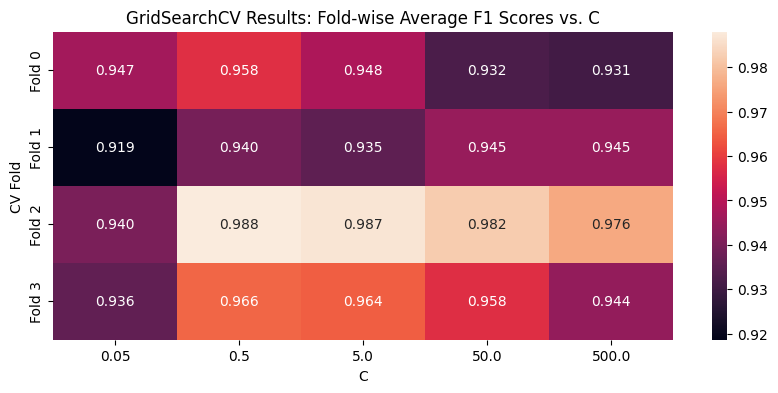

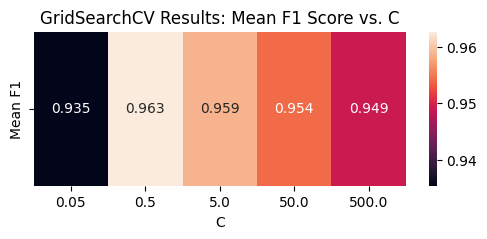

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert cv_results_ to a DataFrame
results_df = pd.DataFrame(gs_log_reg.cv_results_)

# Group by 'C' to compute the average fold-wise test scores across all penalty and class_weight combinations that use the same C
grouped = results_df.groupby('param_classifier__C').mean(numeric_only=True)

# Identify columns for each fold's test scores (split0_test_score, split1_test_score, etc.)
fold_columns = [col for col in grouped.columns if col.startswith('split') and col.endswith('_test_score')]


# Create a 2D array where:
#   - Rows = folds (split0, split1, etc.)
#   - Columns = each 'C' value tested
scores_by_fold_C = np.array([grouped[col].values for col in fold_columns])

# Plot the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    scores_by_fold_C,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title("GridSearchCV Results: Fold-wise Average F1 Scores vs. C")
#plt.suptitle("Average fold-wise F1 scores aggregated across all penalty and class_weight combinations for each C", fontsize=10, y=0.92)
#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.xlabel("C")
plt.ylabel("CV Fold")
plt.show()

# Extract the mean cross-validation scores
mean_scores_by_C = scores_by_fold_C.mean(axis=0)  # shape: (n_C_values,)

# Turn this 1D array into a 2D array with one row (for the heatmap)
mean_scores_C_2d = mean_scores_by_C[np.newaxis, :]  # shape: (1, n_C_values)

# Create the heatmap
plt.figure(figsize=(6, 2))
sns.heatmap(
    mean_scores_C_2d,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=["Mean F1"]
)
plt.title("GridSearchCV Results: Mean F1 Score vs. C")
plt.xlabel("C")
plt.show()


* This top heatmap displays the average F1 scores for each value of C and each cross-validation fold, aggregated over all tested combinations of penalty and class_weight during GridSearchCV. The bottom heatmap presents the overall mean F1 score per C, averaged across all cross-validation folds.

* Overall, as the regularization strength C increases from 0.05 to 0.5, the average F1 score across folds improves, reaching its peak at C = 0.5. However, further increasing C beyond 0.5 results in a gradual decline in performance.

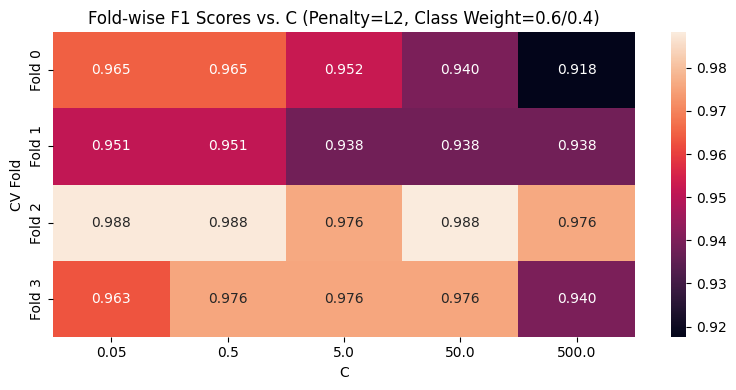

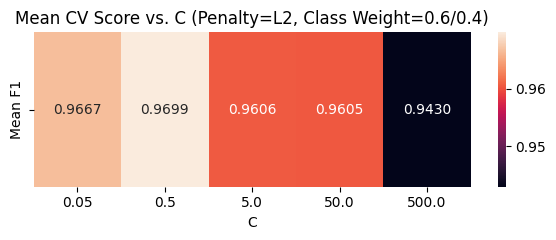

In [ ]:
# Step 1: Filter for penalty='l2' and class_weight={1: 0.6, 0: 0.4}
filtered_df_c = results_df[
    (results_df['param_classifier__penalty'] == 'l2') &
    (results_df['param_classifier__class_weight'] == {1: 0.6, 0: 0.4})
].copy()

# Step 2: Convert C to string for axis label
filtered_df_c['C_str'] = filtered_df_c['param_classifier__C'].astype(str)

# Step 3: Identify fold-wise test scores
fold_columns = [col for col in filtered_df_c.columns if col.startswith('split') and col.endswith('_test_score')]
scores_by_fold_c = np.array([filtered_df_c[col].values for col in fold_columns])

# Step 4: Plot fold-wise F1 score heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    scores_by_fold_c,
    annot=True,
    fmt=".3f",
    xticklabels=filtered_df_c['C_str'].tolist(),
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title("Fold-wise F1 Scores vs. C (Penalty=L2, Class Weight=0.6/0.4)")
plt.xlabel("C")
plt.ylabel("CV Fold")
plt.tight_layout()
plt.show()

# Step 5: Plot mean F1 scores
mean_scores_c = filtered_df_c['mean_test_score'].values
mean_scores_c_2d = mean_scores_c[np.newaxis, :]

plt.figure(figsize=(6, 2.5))
sns.heatmap(
    mean_scores_c_2d,
    annot=True,
    fmt=".4f",
    xticklabels=filtered_df_c['C_str'].tolist(),
    yticklabels=["Mean F1"]
)
plt.title("Mean CV Score vs. C (Penalty=L2, Class Weight=0.6/0.4)")
plt.xlabel("C")
plt.tight_layout()
plt.show()


* The top heatmap shows fold-wise F1 scores across different values of C, with penalty fixed as L2 and class weight fixed as {1: 0.6, 0: 0.4}. It demonstrates that C values around 0.5 and 5 generally yield strong and consistent performance across folds, while higher C values (e.g., 500) lead to a drop in performance.

* The bottom heatmap displays the mean F1 score across all folds for each C value under the same fixed penalty and class weight. The best average performance is observed at C = 0.5 (mean F1 ≈ 0.9699).

#### **Heatmap F1 for each penalty**


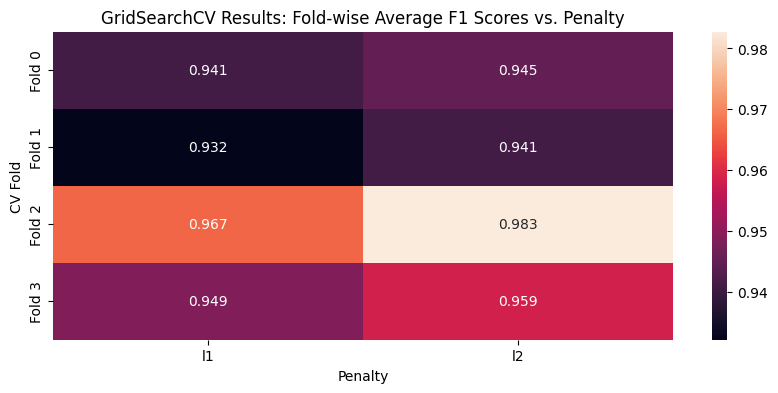

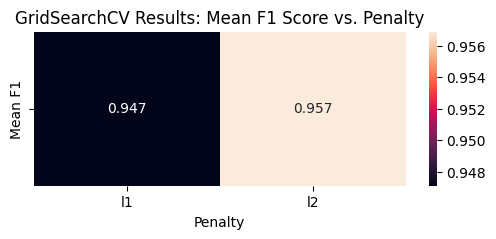

In [ ]:
# Convert cv_results_ to a DataFrame
results_df = pd.DataFrame(gs_log_reg.cv_results_)

# Group by 'C' to compute the average fold-wise test scores across all c and class_weight combinations that use the same penalty
grouped = results_df.groupby('param_classifier__penalty').mean(numeric_only=True)

# Identify columns for each fold's test scores (split0_test_score, split1_test_score, etc.)
fold_columns = [col for col in grouped.columns if col.startswith('split') and col.endswith('_test_score')]


# Create a 2D array where:
#   - Rows = folds (split0, split1, etc.)
#   - Columns = each 'C' value tested
scores_by_fold = np.array([grouped[col].values for col in fold_columns])

# Plot the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    scores_by_fold,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title("GridSearchCV Results: Fold-wise Average F1 Scores vs. Penalty")
plt.xlabel("Penalty")
plt.ylabel("CV Fold")
plt.show()

# Extract the mean cross-validation scores
mean_scores_by_penalty = scores_by_fold.mean(axis=0)  # shape: (n_C_values,)

# Turn this 1D array into a 2D array with one row (for the heatmap)
mean_scores_2d = mean_scores_by_penalty[np.newaxis, :]  # shape: (1, n_C_values)

# Create the heatmap
plt.figure(figsize=(6, 2))
sns.heatmap(
    mean_scores_2d,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=["Mean F1"]
)
plt.title("GridSearchCV Results: Mean F1 Score vs. Penalty")
plt.xlabel("Penalty")
plt.show()


* The top heatmap displays the fold-wise average F1 scores for each penalty type (l1 and l2), aggregated across all combinations of C and class_weight. The bottom heatmap presents the overall mean F1 score per penalty, averaged across all cross-validation folds.

* Overall, the l2 penalty consistently yields higher F1 scores than l1 across all folds. The mean F1 score for l2 is 0.957, compared to 0.947 for l1.

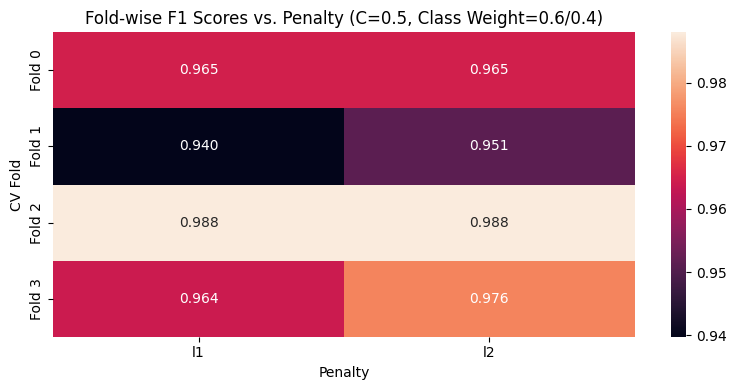

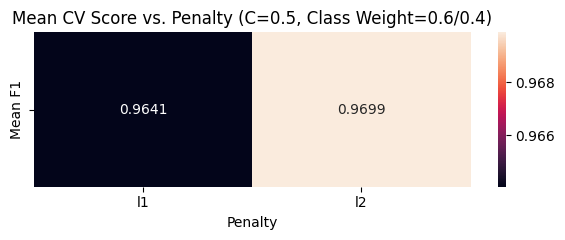

In [ ]:
# Step 1: Filter for C=0.5 and class_weight={1: 0.6, 0: 0.4}
filtered_df_penalty = results_df[
    (results_df['param_classifier__C'] == 0.5) &
    (results_df['param_classifier__class_weight'] == {1: 0.6, 0: 0.4})
].copy()

# Step 2: Convert penalty to string for axis label
filtered_df_penalty['penalty_str'] = filtered_df_penalty['param_classifier__penalty'].astype(str)

# Step 3: Identify fold-wise test scores
fold_columns = [col for col in filtered_df_penalty.columns if col.startswith('split') and col.endswith('_test_score')]
scores_by_fold_penalty = np.array([filtered_df_penalty[col].values for col in fold_columns])

# Step 4: Plot fold-wise F1 score heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    scores_by_fold_penalty,
    annot=True,
    fmt=".3f",
    xticklabels=filtered_df_penalty['penalty_str'].tolist(),
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title("Fold-wise F1 Scores vs. Penalty (C=0.5, Class Weight=0.6/0.4)")
plt.xlabel("Penalty")
plt.ylabel("CV Fold")
plt.tight_layout()
plt.show()

# Step 5: Plot mean F1 scores
mean_scores_penalty = filtered_df_penalty['mean_test_score'].values
mean_scores_penalty_2d = mean_scores_penalty[np.newaxis, :]

plt.figure(figsize=(6, 2.5))
sns.heatmap(
    mean_scores_penalty_2d,
    annot=True,
    fmt=".4f",
    xticklabels=filtered_df_penalty['penalty_str'].tolist(),
    yticklabels=["Mean F1"]
)
plt.title("Mean CV Score vs. Penalty (C=0.5, Class Weight=0.6/0.4)")
plt.xlabel("Penalty")
plt.tight_layout()
plt.show()


* The top heatmap shows fold-wise F1 scores across different penalties (L1 vs. L2), with C fixed at 0.5 and class weight fixed at {1: 0.6, 0: 0.4}. While both penalties perform well, L2 consistently achieves slightly higher scores.

* The bottom heatmap presents the mean F1 score across all folds for each penalty under the same fixed C and class weight. The best performance is observed with L2 regularization (mean F1 ≈ 0.9699), outperforming L1.

#### **Heatmap F1 for each weight**

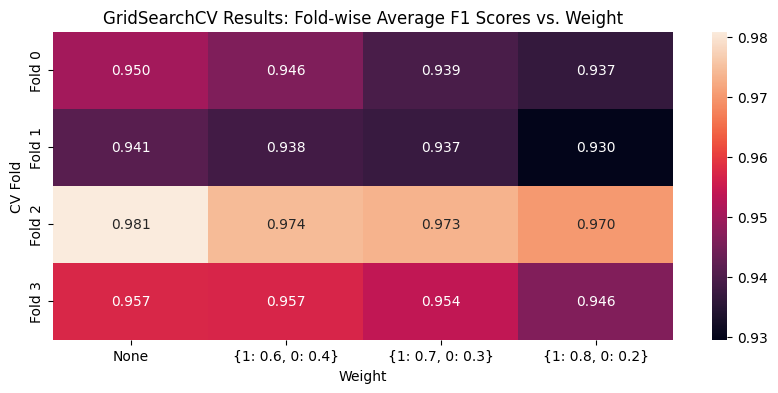

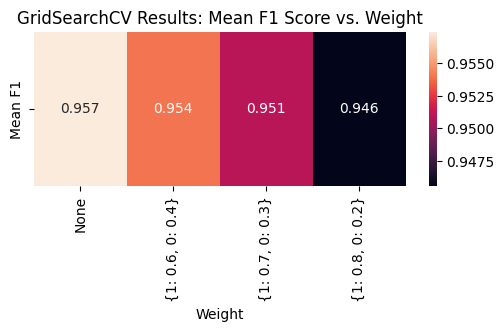

In [ ]:
# Convert class_weight dictionaries to strings since dicts are unhashable and cannot be used as groupby keys
results_df['param_classifier__class_weight_str'] = results_df['param_classifier__class_weight'].astype(str)

# Group the results by class_weight string representation and compute the mean of numeric columns
grouped = results_df.groupby('param_classifier__class_weight_str').mean(numeric_only=True)

# Identify columns for each fold's test scores (split0_test_score, split1_test_score, etc.)
fold_columns = [col for col in grouped.columns if col.startswith('split') and col.endswith('_test_score')]


# Create a 2D array where:
#   - Rows = folds (split0, split1, etc.)
#   - Columns = each 'C' value tested
scores_by_fold_weight = np.array([grouped[col].values for col in fold_columns])

# Plot the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    scores_by_fold_weight,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title("GridSearchCV Results: Fold-wise Average F1 Scores vs. Weight")
plt.xlabel("Weight")
plt.ylabel("CV Fold")
plt.show()

# Extract the mean cross-validation scores
mean_scores_by_weight = scores_by_fold_weight.mean(axis=0)  # shape: (n_C_values,)

# Turn this 1D array into a 2D array with one row (for the heatmap)
mean_scores_weight_2d = mean_scores_by_weight[np.newaxis, :]  # shape: (1, n_C_values)

# Create the heatmap
plt.figure(figsize=(6, 2))
sns.heatmap(
    mean_scores_weight_2d,
    annot=True,
    fmt=".3f",
    xticklabels=grouped.index,
    yticklabels=["Mean F1"]
)
plt.title("GridSearchCV Results: Mean F1 Score vs. Weight")
plt.xlabel("Weight")
plt.show()

* The top heatmap displays the fold-wise average F1 scores for each class weight setting, aggregated across all combinations of C and penalty. The bottom heatmap presents the overall mean F1 score per class weight, averaged across all cross-validation folds.

* Overall, the unweighted (None) setting yields the highest F1 score across folds. The mean F1 score for None is 0.957, compared to 0.954 for {1: 0.6, 0: 0.4}, and lower values for the more imbalanced settings.

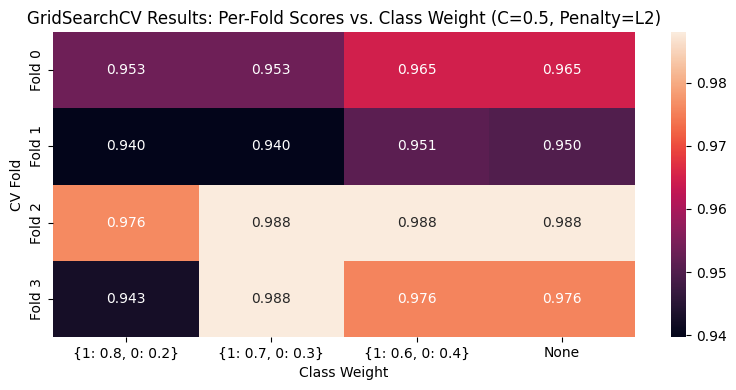

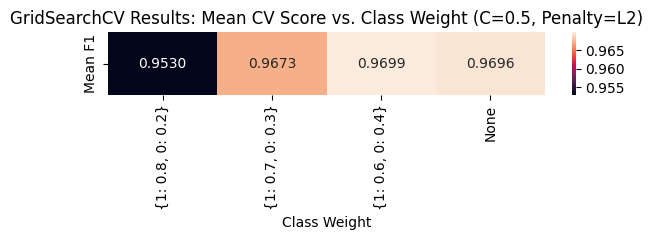

In [ ]:
# Step 1: Filter results to only include rows with C=0.5 and penalty='l2'
filtered_df = results_df[
    (results_df['param_classifier__C'] == 0.5) &
    (results_df['param_classifier__penalty'] == 'l2')
].copy()  # To avoid SettingWithCopyWarning

# Step 2: Convert class_weight dicts to string for labeling
filtered_df['class_weight_str'] = filtered_df['param_classifier__class_weight'].astype(str)

# Step 3: Identify per-fold test score columns (e.g., split0_test_score, split1_test_score, ...)
fold_columns = [col for col in filtered_df.columns if col.startswith('split') and col.endswith('_test_score')]

# Step 4: Create 2D array for heatmap: rows = folds, columns = class weight settings
scores_by_fold = np.array([filtered_df[col].values for col in fold_columns])

# Step 5: Plot per-fold F1 score heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    scores_by_fold,
    annot=True,
    fmt=".3f",
    xticklabels=filtered_df['class_weight_str'].tolist(),
    yticklabels=[f'Fold {i}' for i in range(len(fold_columns))]
)
plt.title('GridSearchCV Results: Per-Fold Scores vs. Class Weight (C=0.5, Penalty=L2)')
plt.xlabel('Class Weight')
plt.ylabel('CV Fold')
plt.tight_layout()
plt.show()

# Step 6: Extract mean CV scores
mean_scores = filtered_df['mean_test_score'].values
mean_scores_2d = mean_scores[np.newaxis, :]  # Reshape to 2D for heatmap

# Step 7: Plot mean F1 score heatmap
plt.figure(figsize=(6, 2.5))
sns.heatmap(
    mean_scores_2d,
    annot=True,
    fmt=".4f",
    xticklabels=filtered_df['class_weight_str'].tolist(),
    yticklabels=['Mean F1']
)
plt.title('GridSearchCV Results: Mean CV Score vs. Class Weight (C=0.5, Penalty=L2)')
plt.xlabel('Class Weight')
plt.tight_layout()
plt.show()


* The top heatmap shows fold-wise F1 scores for each class_weight setting, using only the models with C = 0.5 and penalty = L2.

* The bottom heatmap shows the mean F1 score across all folds for each class_weight under the same fixed hyperparameters.

* Unlike previous plots where C and penalty were not fixed, this analysis isolates their effect.

* When fixing C = 0.5 and penalty = L2, the {1: 0.6, 0: 0.4} class weight setting shows the best performance, with a mean F1 score of 0.9699.

### **Conclusion**

Based on the analysis above, the model achieves a high F1 score for both the training and test datasets, 0.985 and 0.957, respectively. The hyperparameter settings were c=0.5, penalty=l2, and class_weight=0.6, 0.4. To validate these choices, heatmaps were generated for each hyperparameter individually, with and without considering the impacts of other hyperparameters.

* The performance peaked at C = 0.5, beyond which the F1 score.
* The L2 regularisation consistently outperformed L1 regularisation
* Among various weighting schemes, the setting {1: 0.6, 0: 0.4} produced the best performance under fixed C=0.5 and penalty=l2.

This analysis supports the selection of C = 0.5, penalty = 'l2', and class_weight = {1: 0.6, 0: 0.4} as a reliable and stable setting for the classification task.



---



---



---



# <font color="green">**Deployment, Monitoring and Maintenance**</font>




### **Classification Report Analysis**

* Logistic regression was adopted to solve the binary classification problem of predicting whether a tumor is benign or malignant, based on FNA-derived features and patient age. The primary evaluation metric was the F1 score to balance precision and recall, with recall adopted as the secondary metric due to the critical importance of reducing false negatives in a clinical context.

* The results show that the training F1 scores for class 0 and class 1 were 0.99 and 0.98, respectively. The training recall scores were also high, at 0.99 for class 0 and 0.97 for class 1, indicating strong and well-balanced performance on the training set. On the test set, F1 scores dropped slightly to 0.96 for class 0 and 0.95 for class 1, and recall scores were 0.94 for class 0 and 0.98 for class 1. Despite this expected decrease in performance due to generalization, the model still showed strong performance and avoided overfitting. The improved recall for class 1 (malignant) on the test set suggests that assigning a higher class weight to class 1 helped reduce false negatives.

* This result is particularly significant in clinical settings, where failing to identify a malignant case could lead to delayed treatment and worse patient outcomes. By achieving high recall for malignant cases, the model can assist clinicians in identifying potential cancer cases more reliably, thereby improving the chances of early intervention and increasing patient survival rates. This aligns with real-world needs, where medical decisions require both accuracy and reliability, especially in high-stakes diagnoses.

### **Hyper-parameters Heatmap Analysis**

To find the optimal hyperparameters, we implemented GridSearchCV using three parameters: C, class_weight, and penalty. To analyze the effect of each hyperparameter, we generated heatmaps in two settings for each parameter. First, we visualized the performance by grouping results solely based on the target hyperparameter, without considering the influence of the others. Second, we plotted heatmaps while fixing the remaining two hyperparameters to their optimal values, allowing for a more controlled evaluation of the parameter's effect. This two-step approach enables both a broad and focused understanding of each hyperparameter’s impact on model performance.



#### **Heatmap Insights: Regularization Strength (C)**

* The heatmap "Fold-wise Average F1 Scores vs. C" shows that F1 scores consistently improve from C = 0.05 to C = 0.5 across all folds, but begin to decline as C increases further (e.g., to 500). Averaging across folds confirms that C = 0.5 yields the best performance.

* In logistic regression, C is the inverse of regularization strength. A smaller C imposes stronger regularization, which can underfit the model, while a larger C weakens regularization, leading to overfitting and poor generalization. Hence, C = 0.5 offers a well-balanced trade-off, effectively managing both underfitting and overfitting.

* Importantly, when applied in a clinical setting, this balance is essential to ensure generalizability across unseen patients, preventing both missed diagnoses (underfitting) and overconfident misclassifications (overfitting).

* Furthermore, this choice of C performed consistently well across settings with optimized penalty and class weight (e.g., Penalty=L2, Class Weight=0.6/0.4), reinforcing its robustness and reliability.

* Therefore, we conclude that C = 0.5 is not only statistically optimal but also practically deployable, supporting high diagnostic accuracy without overfitting to training data. This is particularly beneficial for clinicians, who rely on models that maintain reliable generalization in diverse real-world patient cases.

#### **Heatmap Insights: Penalty Term (L1 vs L2)**

* The heatmap "*Fold-wise Average F1 Scores vs. Penalty*" shows that the L2 penalty term consistently outperforms the L1 penalty across most folds. When fixing the hyperparameters at C=0.5 and class weight=(0.6, 0.4), the heatmap "Fold-wise F1 Scores vs. Penalty (C=0.5, Class Weight=0.6/0.4)" again shows that L2 outperforms L1 in most folds.

* The reason behind L2's superior performance can be attributed to its tendency to distribute weights more smoothly across features, which is beneficial when all features carry some predictive value—as is often the case in medical data. In contrast, L1 regularization drives many weights to zero, effectively performing feature selection, which can be suboptimal when predictive signals are distributed.

* Thus, in clinical applications where interpretability is important but overall predictive performance is critical, L2 regularization may be preferred due to its better generalization and stability.



#### **Heatmap Insights: Class Weight Settings**

* The heatmap "Fold-wise Average F1 Scores vs. Class Weight" shows that when no class weights were set (None), the model actually achieved the best average F1 score (0.957) across folds. This suggests that in the absence of an optimized setting, the model naturally performed well without any weighting.

* However, the class weight setting {1: 0.6, 0: 0.4} yielded very similar and stable performance (mean F1 = 0.954), outperforming more extreme weightings such as {1: 0.8, 0: 0.2}, which resulted in a noticeable drop in performance (mean F1 = 0.946). This indicates that over-emphasizing the minority class (malignant) can degrade overall performance, possibly due to increased false positives.

* Under the optimized setting (C=0.5, penalty=L2), the class weight {1: 0.6, 0: 0.4} showed slightly better performance (mean F1 = 0.9699) than the None setting (0.9696), even though both performed comparably. Despite the marginal difference, we prefer the {1: 0.6, 0: 0.4} setting because it shifts more attention to class 1, thereby reducing false negatives—a crucial consideration in clinical diagnosis where failing to detect malignancy can lead to delayed treatment or worse patient outcomes.

* Thus, we conclude that while no weighting performs well by default, applying a moderate class weight such as {1: 0.6, 0: 0.4} is clinically safer and ethically responsible when aiming to minimize missed malignant cases, without significantly compromising overall model performance.



These heatmap insights collectively demonstrate that selecting optimal hyperparameters—such as C = 0.5, L2 penalty, and class weight (1: 0.6, 0: 0.4)—leads to a model that achieves a strong balance between sensitivity and specificity, which is essential in medical diagnosis.

Ultimately, this optimized logistic regression model can meaningfully support clinical decision-making by providing robust, interpretable, and generalizable predictions, especially in high-stakes healthcare scenarios.

### **Limitations**

* **Linear Assumptions**: The logistic regression model assumes a linear relationship between input features and the log-odds of the outcome. This may fail to capture complex non-linear patterns often found in real-world medical data, potentially limiting predictive accuracy. If raw tumor images are used as the dataset instead of structured data in a dataframe, more complex models such as convolutional neural networks (CNNs) would be required to capture non-linear and spatial relationships effectively.

* **Moderate Performance with Class Imbalance**: Although class weighting was applied to address imbalance, performance may still degrade when faced with more severe real-world imbalance scenarios (e.g., rare cancer types), requiring alternative techniques like sampling or ensemble methods (e.g., boosting to emphasize misclassified minority examples), or larger datasets.

* **Static Model**: The current model is static and may become outdated as clinical practices, population demographics, or diagnostic criteria evolve over time. Without continuous retraining or monitoring, this drift can reduce the model's effectiveness in deployment.

* **Limited Training Data**: The model was trained and validated on a relatively small dataset. This raises concerns about its generalizability to broader and more diverse patient populations. Large-scale retraining and testing are necessary to ensure robustness.

* **Residual False Negatives**: Despite achieving high recall, the model still produces false negatives, which is critical in medical diagnosis. Failing to detect malignant cases could delay treatment. Therefore, human oversight remains essential, and clinicians should always double-check predictions, particularly in ambiguous or high-risk cases.



### **Ethical and Stakeholder Considerations**

* Clinicians are the primary stakeholders, and the model’s high recall supports better patient safety. However, false positives — while less risky — can still cause patient anxiety and unnecessary testing. The model must be used as a clinical decision support tool, not a standalone diagnostic method. Transparency and explainability are vital for clinician trust, and it’s essential that patients are informed that AI tools are being used in their diagnosis pipeline.

### **Deployment Recommendation**

Given its high recall, interpretability, and robustness under optimized hyperparameters, I would recommend deploying the model in a clinical decision-support context, with the following precautions:

* Human-in-the-loop verification must be enforced to prevent overreliance on automated decisions.

* Clinical validation is needed on diverse, external datasets to ensure the model generalizes across populations.

### **Monitoring and Maintenance**

* As new patient data is collected, the model should be retrained periodically to maintain relevance.

* Regularly assess model performance across demographic subgroups to detect and mitigate potential bias.

* Incorporate clinician feedback on model predictions to flag incorrect decisions and support ongoing improvements.



---



---



---



### **Classification Report Analysis**

* Logistic regression was adopted to solve the binary classification problem of predicting whether a tumor is benign or malignant, based on FNA-derived features and patient age. The primary evaluation metric was the F1 score to balance precision and recall, with recall adopted as the secondary metric due to the importance of reducing false negatives in a clinical context.

* The results show that the training F1 scores for class 0 and class 1 were 0.99 and 0.98, respectively. The training recall scores were also high, at 0.99 for class 0 and 0.97 for class 1, showing strong and well-balanced performance on the training set. On the test set, F1 scores dropped slightly to 0.96 for class 0 and 0.95 for class 1, and recall scores were 0.94 for class 0 and 0.98 for class 1. Despite this expected decrease in performance due to generalization, the model still showed outstanding performance and avoided overfitting. The improved recall for class 1 (malignant) on the test set suggests that assigning a higher class weight to class 1 helped reduce false negatives.

* This finding is particularly important in the clinical area since a missed case of malignancy prevents timely therapy and decreases patient survival. Because of the high recall of the malignancy cases, the model can help clinicians to capture potential cancer more consistently, and early intervention will result in more patients’ lives to be saved. This reflects real-life scenarios where medical decisions are driven by the need for both high accuracy and reliability, particularly in high risk diagnoses.



### **Hyper-parameters Heatmap Analysis**

* To obtain an optimal hyperparameter setting, we employed GridSearchCV with C, class_weight and penalty. To observe the impact of each hyperparameter, heatmaps were created in two contexts. First, we have visualized the performance by binning results by target hyperparameter, without taking into account the effect of other hyperparameters. Second, we generated heatmaps while holding the two remaining hyperparameters to their optimal, making it possible to assess the effect more isolated.

#### **Heatmap Insights: Regularization Strength (C)**

* The heatmap "Fold-wise Average F1 Scores vs. C" shows that F1 scores consistently improve from C = 0.05 to C = 0.5 across all folds, but begin to decline as C increases further (e.g., to 500). Averaging across folds confirms that C = 0.5 give best performance.


* For logistic regression, C is the inverse of regularization strength. A less C induces more regularization and risk underfitting the model and a larger C induces the weaker regularization, causing overfitting and poor generalization. Therefore, the C value of 0.5 demonstrates the best trade-off, which efficiently controls both underfitting and overfitting.



* Crucially, such balance is required to address generalizability across unseen patients when deployed in a clinical setting preventing both the missing/presence of diagnoses (underfit) and overly confident misclassifications.
Furthermore, this choice of C performed consistently well across settings with optimized penalty and class weight (e.g., Penalty=L2, Class Weight=0.6/0.4), reinforcing its robustness and reliability.
Hence we believe that C = 0.5 is not only statistically best but also practically applicable, that can make a great diagnostic accuracy without overtraining like as to training data. This is particularly useful for clinicians who need models which maintain accurate generalization across diverse real-world patient cases.


#### **Heatmap Insights: Penalty Term (L1 vs L2)**

* It can be observed from the heatmap "Fold-wise Average F1 Scores vs. Penalty" that in each fold, the penalty with L2 term yields better overall performance over the L1 penalty. Given the hyperparameters C=0.5 and class weight=(0.6, 0.4), the heatmap "Fold-wise F1 Scores vs. Penalty (C=0.5, Class Weight=0.6/0.4)" shows that L2 beats L1 in most of the folds.

* The advantage of L2 could be due to its propensity to spread the weights more evenly across features, which is beneficial when all features have some predictive value, as is usually the case in medical data. L1 regularization, however, leads many weights to being zero (larger than zero) values, effectively performing feature selection and can be ineffective when predictive signals are spread out.

* Therefore, for clinical tasks where interpretability is essentially required but overall performance is also important, L2 regularization may be advantageous because of the better generalization and stability.

#### **Heatmap Insights: Class Weight Settings**

* The heatmap “Fold-wise Average F1 Scores vs. Class Weight” confirms that with no class weights (None), the model had the highest average F1 score (0.957) among the 10 folds (cross-validation). This implied that without a model specific setting, the model actually did unparalleled work without any weight adjustment.

* Instead, the class weight {1: 0.6, 0: 0.4} provided similar very good and consistent performance (mean F1 = 0.954), and performed much better than more extreme weightings (e.g., {1: 0.8, 0: 0.2}, had significantly lower performance (mean F1 = 0.946)). This implies that over-emphasizing the minority class (malignant) can damage overall performance even though it increases the detection of the class, potentially by increasing the number of false positives.

* The class weight {1: 0.6, 0: 0.4} was found to exhibit marginally better performance (mean F1 = 0.9699), in comparison with None (0.9696) in optimized setting (C=0.5, penalty=L2) regardless of the mean F1 being similar. Although the difference is small, we chose to use the {1: 0.6, 0: 0.4} configuration because it allocates more attention to class 1, which ultimately lowers the rate of false negatives—a consideration of significance for clinical diagnosis, as failing to diagnose malignant tumours can result in a delay of treatment or worse patient outcomes.

* In this way, we can infer that no weight works well by default, but a class weight of moderate class weight such as {1:0.6, 0:0.4} is clinically safer and ethically warranted, if we want to keep the missed malignant cases at a minimum, without however affecting harshly the overall model's performance.

Taken together, these heatmap interpretations illustrate that optimal hyperparameters afford a good trade-off between sensitivity and specificity that is quite useful for medical diagnosis. Finally, this optimal logistic regression model should be helpful to clinicians in making decisions, by producing powerful, interpretable and generalisable prediction, especially, in the high stakes health care.

### **Limitations**

* **Linear Assumption**: Logistic regression assumes linearity of the features  and the log-odds of the dependent variable. This fails to take into account complex non-linear relationships which are typical in real-world medical data, possibly resulting in a poor predictive accuracy. When raw tumor images are entered, rather than the structured data in a dataframe, a more complex model like a CNN would be needed to better capture non-linear and spatial relationship.

* **Moderate Performance and Class Imbalance**: Class weighting is used to combat class imbalance and may not always be sufficient in the face of far more extreme real-world imbalance scenarios (rare cancer types) and other techniques may be required, such as sampling or ensemble methods (e.g., boosting to give higher weight to misclassified minority examples) or more data.

* **Static Model**: The model in its current form is static and there will be no updates should clinical practice, population demographics, or diagnostic criteria change over time. This drift can cause the model to underperform in deployment without ongoing retraining or monitoring.

* **Limited Number of Training Samples**: The model was trained and validated on a small dataset. This calls into question its applicability in populations with broader phenotypic diversity. Retraining and testing in large-scale are required for robustness.

* **False Negatives**: The model has high recall, but there still remains false negatives, more important in the context of medical diagnosis. If malignancy is missed, patients may be inappropriately delayed in treatment. So, here again human confirmation is a necessity, and health practitioners should always verify predictions, especially those provided in ambiguous or high-risk circumstances.

### **Ethical and Stakeholder Considerations**

* Physicians are the key stakeholders and the high model recall lead to overall better patient safety. But false positives — while not as dangerous — raise patient anxiety and lead to unnecessary testing. The model should be used as a clinical decision support, and is not a diagnosis tool by itself. Transparency and explainability are key for clinician trust, and it is important that patients are informed when AI tools are involved in their diagnosis pipeline.

### **Deployment Recommendation**

Given its high recall, interpretability, and robustness under optimized hyperparameters, I would recommend deploying the model in a clinical decision-support context, with the following precautions:

* Human-in-the-loop verification must be enforced to prevent overreliance on automated decisions.

* Clinical validation is needed on diverse, external datasets to ensure the model generalizes across populations.

### **Monitoring and Maintenance**

* As new patient records become available, the model should be retrained periodically to ensure timeliness.

* Also monitoring model performance on demographic subgroups would be beneficial to identify and address bias.

* In addition, adding clinician input to model predictions would be helpful to alert for a wrong decision for continuously improved performance.